In [1]:
# use float64'
from jax import config
config.update("jax_enable_x64", True)

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import optax

from hybrid_models.hh import *
from hybrid_models.hh import integrate
from hybrid_models.utils import tree_path_of_leaves, tree_set_with_path, tree_filter_by_path, Dataset
from hybrid_models.transforms import ParamTransform, LogisticTransform, ModelParamTransform
import equinox as eqx

import matplotlib.pyplot as plt

import os
import sys
sys.path.append('../')
import pickle

from scripts.configs import *
import diffrax

import json
import pandas as pd
import numpy as np

FULL_WIDTH = 5.521
HALF_WIDTH = FULL_WIDTH / 2
plt.style.use("../.matplotlibrc")

In [3]:
import re

def df_to_latex(
    df,
    highlight_vals=None,
    col_fmt=None,
    include_index=False,
    hlines=True,
    float_format="%.2f",
    mean_pm_std=False,
):
    """
    Convert DataFrame to LaTeX table.
    highlight_vals: one entry per column -> None, "max", or "min".
    Matching values (ties allowed) are wrapped in \\textbf{}.

    If mean_pm_std is True, columns named mean_x and std_x are merged into a
    single column named x with entries formatted as "mean \\pm std" using
    float_format. Highlighting for such merged columns is applied based on the
    numeric mean values.
    """
    df2 = df.copy()
    original_cols = list(df2.columns)
    ncols = df2.shape[1]

    if highlight_vals is None:
        highlight_vals = [None] * ncols
    if len(highlight_vals) != ncols:
        raise ValueError("highlight_vals must have one entry per column")

    def _fmt_val(v):
        if pd.isna(v):
            return ""
        try:
            if callable(float_format):
                return float_format(float(v))
            if isinstance(float_format, str) and "%" in float_format:
                return float_format % float(v)
            return format(float(v), float_format)
        except Exception:
            return str(v)

    merged_means_map = {}
    if mean_pm_std:
        mean_pref = "mean_"
        std_pref = "std_"
        merged_values = {}
        modes_map = {}

        for i, col in enumerate(original_cols):
            if col.startswith(mean_pref):
                base = col[len(mean_pref) :]
                mean_ser = pd.to_numeric(df2[col], errors="coerce")
                std_col = std_pref + base

                if std_col in original_cols:
                    std_ser = pd.to_numeric(df2[std_col], errors="coerce")
                    std_idx = original_cols.index(std_col)
                    modes_map[base] = (
                        highlight_vals[i]
                        if highlight_vals[i] is not None
                        else highlight_vals[std_idx]
                    )
                else:
                    std_ser = pd.Series([pd.NA] * len(df2), index=df2.index)
                    modes_map[base] = highlight_vals[i]

                merged_means_map[base] = mean_ser

                merged_values[base] = pd.Series(
                    [
                        (
                            f"{_fmt_val(m)} $\\pm$ {_fmt_val(s)}"
                            if not pd.isna(s)
                            else _fmt_val(m)
                        )
                        if not pd.isna(m)
                        else ""
                        for m, s in zip(mean_ser, std_ser)
                    ],
                    index=df2.index,
                )

        out_cols = []
        for col in original_cols:
            if col.startswith(mean_pref):
                out_cols.append(col[len(mean_pref) :])
            elif col.startswith(std_pref):
                base = col[len(std_pref) :]
                if base in out_cols:
                    continue
                out_cols.append(col)
            else:
                out_cols.append(col)

        for base, ser in merged_values.items():
            df2[base] = ser

        to_drop = [
            c for c in df2.columns if c.startswith(mean_pref) or c.startswith(std_pref)
        ]
        df2 = df2.drop(columns=to_drop, errors="ignore")

        final_cols = [c for c in out_cols if c in df2.columns]
        df2 = df2[final_cols]

        new_highlight = []
        for col in df2.columns:
            if col in modes_map:
                new_highlight.append(modes_map[col])
            elif col in original_cols:
                new_highlight.append(highlight_vals[original_cols.index(col)])
            else:
                new_highlight.append(None)
        highlight_vals = new_highlight
        ncols = df2.shape[1]

    # Apply float formatting only to floating-point columns
    for i, col in enumerate(df2.columns):
        if col in merged_means_map:
            continue
        try:
            if pd.api.types.is_float_dtype(df2[col]):
                ser_num = pd.to_numeric(df2[col], errors="coerce")
                df2[col] = ser_num.map(lambda x: _fmt_val(x) if not pd.isna(x) else "")
        except Exception:
            pass

    for i, mode in enumerate(highlight_vals):
        if mode is None:
            continue
        mode_l = str(mode).lower()
        if mode_l not in {"max", "min"}:
            continue

        col = df2.columns[i]
        if col in merged_means_map:
            ser_num = merged_means_map[col]
        else:
            ser = df2[col]
            ser_num = pd.to_numeric(ser, errors="coerce")
        if ser_num.dropna().empty:
            continue

        target = ser_num.max() if mode_l == "max" else ser_num.min()
        mask = ser_num == target

        df2[col] = df2[col].astype(object)
        df2.loc[mask, col] = df2.loc[mask, col].map(lambda x: f"\\textbf{{{x}}}")
        df2[col] = df2[col].astype(str)

    tabular_str = df2.to_latex(
        index=include_index,
        escape=False,
        column_format=col_fmt,
        float_format=float_format,
    )

    if hlines:
        lines = tabular_str.splitlines()
        out = []
        in_tabular = False

        for line in lines:
            s = line.strip()

            if s.startswith(r"\begin{tabular"):
                in_tabular = True
                out.append(line)
                out.append(r"\hline")
                continue

            if s.startswith(r"\end{tabular"):
                in_tabular = False
                out.append(line)
                continue

            if s in {r"\toprule", r"\midrule", r"\bottomrule"}:
                continue

            out.append(line)
            if in_tabular and s.endswith(r"\\"):
                out.append(r"\hline")

        tabular_str = "\n".join(out)

    latex_str = "\\begin{table}[ht]\n\\centering\n"
    latex_str += tabular_str + "\n"
    latex_str += "\\end{table}"
    return latex_str

def latex_to_str(latex_table):

    m = re.search(r"\\begin{tabular}{.*?}(.*?)\\end{tabular}", latex_table, re.S)
    if not m:
        raise ValueError("no tabular found in input")
    inner = m.group(1)

    # remove explicit \hline markers and any LaTeX rules
    inner = re.sub(r"\\hline", "", inner)
    inner = re.sub(r"\\toprule|\\midrule|\\bottomrule", "", inner)

    # split rows on LaTeX row terminator (\\\\)
    parts = re.split(r"\\\\\s*\n?", inner)
    rows = []
    for part in parts:
        s = part.strip()
        if not s:
            continue
        # drop stray leading/trailing & from pandas multiindex formatting
        s = s.strip("& ")
        cols = [c.strip() for c in s.split("&")]

        def _clean(cell: str) -> str:
            cell = cell.strip()
            # \textbf{...} -> **...**
            cell = re.sub(r"\\textbf\{([^}]*)\}", r"**\1**", cell)
            # \pm -> ±
            cell = cell.replace(r"\pm", "±")
            # remove remaining LaTeX grouping braces
            cell = cell.replace("{", "").replace("}", "")
            # remove math $ if present
            cell = cell.replace("$", "")
            # collapse whitespace
            cell = re.sub(r"\s+", " ", cell).strip()
            return cell

        cols = [_clean(c) for c in cols]
        rows.append(cols)

    if not rows:
        return ""

    header = rows[0]
    data = rows[1:]

    # ensure all rows have same length as header
    for i, r in enumerate(data):
        if len(r) < len(header):
            data[i] = r + [""] * (len(header) - len(r))
        elif len(r) > len(header):
            data[i] = r[: len(header)]

    # build markdown table (right-aligned for numeric-looking columns)
    md_lines = []
    md_lines.append("| " + " | ".join(header) + " |")
    # choose alignment as right for all columns to match example
    md_lines.append("|" + "|".join(["---:"] * len(header)) + "|")
    for r in data:
        md_lines.append("| " + " | ".join(r) + " |")

    return "\n".join(md_lines)
    

In [4]:
config = train_hybrid_on_hh_k()
val_data = Dataset.from_file("../" + config.val_fpath)
v_val = val_data.Y["v"][0]

EXP_DIR = "../results/sweeps/hh_channel_obs_noise_sweep4/"
json_files = [f for f in os.listdir(EXP_DIR) if f.endswith(".json")]

rmse = lambda x, y: jnp.sqrt(jnp.mean((x - y) ** 2))
conv_thresh = 2.0

df = pd.DataFrame(columns=["obs_noise", "rmse", "pred", "converged"])
for json_file in json_files:
    fpath = os.path.join(EXP_DIR, json_file)
    with open(fpath, "r") as f:
        loaded_data = json.load(f)
        val_data = loaded_data["validation_data"]
        v_noise = np.array(val_data["val"]["v"][0])
        v_pred = np.array(val_data["pred"]["v"][0])

        rmse_val = rmse(v_val, v_pred)
        noise = loaded_data["obs_noise"]
        df.loc[len(df)] = [noise, rmse_val, v_pred, int(rmse_val < conv_thresh)]

std_rmse = df[["obs_noise", "rmse", "converged"]].groupby("obs_noise").std()
mean_rmse = df[["obs_noise", "rmse", "converged"]].groupby("obs_noise").mean()
obs_noise_table = pd.DataFrame({
    r"$\sigma_{V}$": mean_rmse.index,
    "mean_RMSE": mean_rmse["rmse"].values,
    "std_RMSE": std_rmse["rmse"].values,
    "min. RMSE": df.groupby("obs_noise")["rmse"].min().astype(float).values,
    "frac converged": mean_rmse["converged"].values,
})

print(obs_noise_table)

   $\sigma_{V}$  mean_RMSE   std_RMSE  min. RMSE  frac converged
0          0.00   7.934506  17.054659   0.625497            0.85
1          0.01  12.003387  19.807479   0.508345            0.75
2          0.05   8.463081  16.385200   0.383047            0.80
3          0.10  17.743275  19.767260   0.654850            0.40


In [75]:
config = train_hybrid_on_hh_k()
val_data = Dataset.from_file("../" + config.val_fpath)
v_val = val_data.Y["v"][0]

EXP_DIR = "../results/sweeps/hh_channel_init_noise_sweep5/"
json_files = [f for f in os.listdir(EXP_DIR) if f.endswith(".json")]

rmse = lambda x, y: jnp.sqrt(jnp.mean((x - y) ** 2))
conv_thresh = 2.0

df = pd.DataFrame(columns=["param_noise", "rmse", "pred", "converged"])
for json_file in json_files:
    fpath = os.path.join(EXP_DIR, json_file)
    with open(fpath, "r") as f:
        loaded_data = json.load(f)
        noise = loaded_data["param_noise"]
        if "validation_data" in loaded_data:
            val_data = loaded_data["validation_data"]
            v_noise = np.array(val_data["val"]["v"][0])
            v_pred = np.array(val_data["pred"]["v"][0])

            rmse_val = rmse(v_val, v_pred)
            conv = rmse_val < conv_thresh
        else:
            print(f"validation data not found in {json_file} for noise {noise}")
            rmse_val = np.nan
            v_pred = np.full_like(v_val, np.nan)
            conv = False
        df.loc[len(df)] = [noise, rmse_val, v_pred, int(conv)]

std_rmse = df[["param_noise", "rmse", "converged"]].groupby("param_noise").std()
mean_rmse = df[["param_noise", "rmse", "converged"]].groupby("param_noise").mean()
param_noise_table = pd.DataFrame({
    r"$\sigma_{\theta}$": mean_rmse.index,
    "mean_RMSE": mean_rmse["rmse"].values,
    "std_RMSE": std_rmse["rmse"].values,
    "min. RMSE": df.groupby("param_noise")["rmse"].min().astype(float).values,
    "frac converged": mean_rmse["converged"].values,
})

print(param_noise_table)

   $\sigma_{\theta}$  mean_RMSE   std_RMSE  min. RMSE  frac converged
0               0.00   8.288333  17.446414   0.625497        0.842105
1               0.01  15.289124  22.621297   0.569392        0.700000
2               0.02  14.738766  21.449552   0.455680        0.700000
3               0.05  13.239599  17.330661   1.030875        0.500000


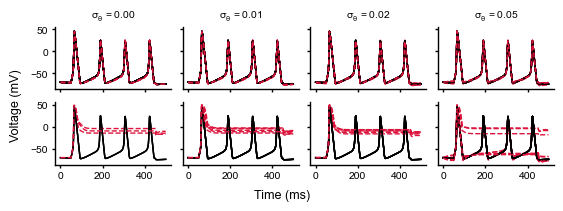

In [83]:
noise_lvls = param_noise_table[r"$\sigma_{\theta}$"]
fig, axes = plt.subplots(2, len(noise_lvls), figsize=(FULL_WIDTH, 2.0), sharey=True, sharex=True, constrained_layout=True)

for json_file in json_files:
    fpath = os.path.join(EXP_DIR, json_file)
    with open(fpath, "r") as f:
        loaded_data = json.load(f)
        noise = loaded_data["param_noise"]
    
        val_data = loaded_data["validation_data"]
        v_noise = np.array(val_data["val"]["v"][0])
        v_pred = np.array(val_data["pred"]["v"][0])

        rmse_val = rmse(v_val, v_pred)
        conv = rmse_val < conv_thresh

        ax_col = axes[:, noise_lvls[noise_lvls == noise].index[0]]
        ax = ax_col[0] if conv else ax_col[1]
        ax.plot(v_noise, label="noisy", c="k")
        ax.plot(v_pred, label="predicted", ls="--", c="crimson")
        ax_col[0].set_title(r"$\sigma_{\theta}$" + f" = {noise:.2f}")
fig.supxlabel("Time (ms)")
fig.supylabel("Voltage (mV)")


plt.savefig("../figures/paper/tab_app2.pdf", dpi=300, transparent=True, bbox_inches="tight")
plt.savefig("../figures/paper/tab_app2.png", dpi=300, transparent=True, bbox_inches="tight")

In [7]:
param_noise_table

,$\sigma_{\theta_0}$,mean_RMSE,std_RMSE,min. RMSE,frac converged
0,0.00,8.288333,17.446414,0.625497,0.842105
1,0.01,15.289124,22.621297,0.569392,0.700000
2,0.02,14.738766,21.449552,0.455680,0.700000
3,0.05,13.239599,17.330661,1.030875,0.500000


In [80]:
col_order = [r"$\sigma_{V}$", r"$\sigma_{\theta}$", "mean_RMSE", "std_RMSE", "min. RMSE", "frac converged"]
table = pd.concat([obs_noise_table, param_noise_table])
table = table[col_order].fillna(0.0).drop_duplicates([r"$\sigma_{V}$", r"$\sigma_{\theta}$"]).reset_index(drop=True)
table

,$\sigma_{V}$,$\sigma_{\theta}$,mean_RMSE,std_RMSE,min. RMSE,frac converged
0,0.00,0.00,7.934506,17.054659,0.625497,0.85
1,0.01,0.00,12.003387,19.807479,0.508345,0.75
2,0.05,0.00,8.463081,16.385200,0.383047,0.80
3,0.10,0.00,17.743275,19.767260,0.654850,0.40
4,0.00,0.01,15.289124,22.621297,0.569392,0.70
5,0.00,0.02,14.738766,21.449552,0.455680,0.70
6,0.00,0.05,13.239599,17.330661,1.030875,0.50


In [42]:
latex_noise_table = df_to_latex(table, highlight_vals=[None, None, "min", None, "min", "max"], mean_pm_std=True, float_format="%.2f", col_fmt="cccccc", hlines=False)
print(latex_noise_table)

\begin{table}[ht]
\centering
\begin{tabular}{cccccc}
\toprule
$\sigma_{V}$ & $\sigma_{\theta_0}$ & RMSE & min. RMSE & frac converged \\
\midrule
0.00 & 0.00 & \textbf{7.93 $\pm$ 17.05} & 0.63 & \textbf{0.85} \\
0.01 & 0.00 & 12.00 $\pm$ 19.81 & 0.51 & 0.75 \\
0.05 & 0.00 & 8.46 $\pm$ 16.39 & \textbf{0.38} & 0.80 \\
0.10 & 0.00 & 17.74 $\pm$ 19.77 & 0.65 & 0.40 \\
0.00 & 0.01 & 15.29 $\pm$ 22.62 & 0.57 & 0.70 \\
0.00 & 0.02 & 14.74 $\pm$ 21.45 & 0.46 & 0.70 \\
0.00 & 0.05 & 13.24 $\pm$ 17.33 & 1.03 & 0.50 \\
\bottomrule
\end{tabular}

\end{table}


In [43]:
print(latex_to_str(latex_noise_table))

| \sigma_V | \sigma_\theta_0 | RMSE | min. RMSE | frac converged |
|---:|---:|---:|---:|---:|
| 0.00 | 0.00 | **7.93 ± 17.05** | 0.63 | **0.85** |
| 0.01 | 0.00 | 12.00 ± 19.81 | 0.51 | 0.75 |
| 0.05 | 0.00 | 8.46 ± 16.39 | **0.38** | 0.80 |
| 0.10 | 0.00 | 17.74 ± 19.77 | 0.65 | 0.40 |
| 0.00 | 0.01 | 15.29 ± 22.62 | 0.57 | 0.70 |
| 0.00 | 0.02 | 14.74 ± 21.45 | 0.46 | 0.70 |
| 0.00 | 0.05 | 13.24 ± 17.33 | 1.03 | 0.50 |


In [44]:
from datetime import datetime

config = train_hybrid_on_hh_k()
val_data = Dataset.from_file("../" + config.val_fpath)
v_val = val_data.Y["v"][0]

EXP_DIR = "../results/sweeps/hh_channel_arch_sweep3/"
json_files = [f for f in os.listdir(EXP_DIR) if f.endswith(".json")]
log_files = [f for f in os.listdir(EXP_DIR) if f.endswith(".log")]

rmse = lambda x, y: jnp.sqrt(jnp.mean((x - y) ** 2))
conv_thresh = 5.0

df = pd.DataFrame(columns=["width", "depth", "activation", "RMSE", "pred", "converged", "opt_time"])
for json_file, log_file in zip(json_files, log_files):
    fpath = os.path.join(EXP_DIR, log_file)
    
    with open(fpath, "r") as f:
        logf_header = f.read()[:2000]
        activation_index = logf_header.find("'activation': ") + len("'activation': ")
        act_name = logf_header[activation_index:].split(" ")[3]

    fpath = os.path.join(EXP_DIR, json_file)
    with open(fpath, "r") as f:
        loaded_data = json.load(f)
        width = loaded_data["channel_model_kwargs"]["width_size"]
        depth = loaded_data["channel_model_kwargs"]["depth_size"]
        opt_time_raw = loaded_data.get("elapsed_time")
        dt = datetime.strptime(opt_time_raw, "%Hh:%Mm:%S.%fs")
        opt_time = dt.hour * 3600 + dt.minute * 60 + dt.second + dt.microsecond / 1e6
        val_data = loaded_data["validation_data"]
        v_noise = np.array(val_data["val"]["v"][0])
        v_pred = np.array(val_data["pred"]["v"][0])
        rmse_val = rmse(v_val, v_pred)
        df.loc[len(df)] = [width, depth, act_name, rmse_val, v_pred, int(rmse_val < conv_thresh), opt_time]

std_rmse = df[["width", "depth", "RMSE", "activation", "converged", "opt_time"]].groupby(["width", "depth", "activation"]).std()
mean_rmse = df[["width", "depth", "RMSE", "activation", "converged", "opt_time"]].groupby(["width", "depth", "activation"]).mean()

arch_table = pd.DataFrame({
    "width": mean_rmse.index.get_level_values("width").astype(int),
    "depth": mean_rmse.index.get_level_values("depth").astype(int),
    "activation": mean_rmse.index.get_level_values("activation"),
    "mean_RMSE": mean_rmse["RMSE"].values,
    "std_RMSE": std_rmse["RMSE"].values,
    "min. RMSE": df.groupby(["width", "depth", "activation"])["RMSE"].min().astype(float).values,
    "frac converged": mean_rmse["converged"].values,
    "mean_runtime (min)": mean_rmse["opt_time"].values / 60, # in mins
    "std_runtime (min)": std_rmse["opt_time"].values / 60, # in mins
})

In [47]:
latex_arch_table = df_to_latex(arch_table, highlight_vals=[None, None, None, "min", None, "min", "max", "min", None], mean_pm_std=True, float_format="%.2f", col_fmt="ccccccccc", hlines=False)
print(latex_arch_table)

\begin{table}[ht]
\centering
\begin{tabular}{ccccccccc}
\toprule
width & depth & activation & RMSE & min. RMSE & frac converged & runtime (min) \\
\midrule
8 & 2 & mish & 20.63 $\pm$ 4.49 & 5.06 & 0.00 & 5.07 $\pm$ 0.58 \\
8 & 2 & silu & 19.97 $\pm$ 2.40 & 13.14 & 0.00 & 5.18 $\pm$ 0.44 \\
8 & 2 & softplus & 19.05 $\pm$ 4.91 & 6.21 & 0.00 & 5.32 $\pm$ 0.58 \\
8 & 2 & tanh & 17.44 $\pm$ 6.32 & 4.60 & 0.09 & 5.21 $\pm$ 0.33 \\
8 & 3 & mish & 22.23 $\pm$ 2.15 & 19.64 & 0.00 & 5.49 $\pm$ 0.56 \\
8 & 3 & silu & 19.30 $\pm$ 4.70 & 4.76 & 0.05 & 5.47 $\pm$ 0.63 \\
8 & 3 & softplus & 18.85 $\pm$ 5.53 & 4.70 & 0.04 & 5.50 $\pm$ 0.63 \\
8 & 3 & tanh & 21.17 $\pm$ 4.75 & 12.02 & 0.00 & 5.66 $\pm$ 0.61 \\
16 & 2 & mish & 28.31 $\pm$ 17.84 & 3.34 & 0.10 & 4.86 $\pm$ 0.46 \\
16 & 2 & silu & 30.41 $\pm$ 19.42 & 4.71 & 0.06 & 4.82 $\pm$ 0.52 \\
16 & 2 & softplus & 34.38 $\pm$ 18.33 & 12.18 & 0.00 & 4.77 $\pm$ 0.41 \\
16 & 2 & tanh & 39.10 $\pm$ 17.70 & 13.19 & 0.00 & \textbf{4.70 $\pm$ 0.50} \\
16 & 3

In [46]:
print(latex_to_str(latex_arch_table))


| width | depth | activation | RMSE | min. RMSE | frac converged | runtime (min) |
|---:|---:|---:|---:|---:|---:|---:|
| 8 | 2 | mish | 20.626 ± 4.491 | 5.063 | 0.000 | 5.072 ± 0.577 |
| 8 | 2 | silu | 19.969 ± 2.397 | 13.136 | 0.000 | 5.183 ± 0.444 |
| 8 | 2 | softplus | 19.048 ± 4.911 | 6.206 | 0.000 | 5.323 ± 0.582 |
| 8 | 2 | tanh | 17.443 ± 6.317 | 4.595 | 0.087 | 5.207 ± 0.332 |
| 8 | 3 | mish | 22.234 ± 2.148 | 19.638 | 0.000 | 5.489 ± 0.561 |
| 8 | 3 | silu | 19.303 ± 4.697 | 4.759 | 0.048 | 5.467 ± 0.629 |
| 8 | 3 | softplus | 18.847 ± 5.534 | 4.698 | 0.042 | 5.496 ± 0.626 |
| 8 | 3 | tanh | 21.173 ± 4.751 | 12.016 | 0.000 | 5.659 ± 0.608 |
| 16 | 2 | mish | 28.305 ± 17.840 | 3.344 | 0.100 | 4.858 ± 0.461 |
| 16 | 2 | silu | 30.406 ± 19.424 | 4.714 | 0.059 | 4.819 ± 0.522 |
| 16 | 2 | softplus | 34.378 ± 18.334 | 12.183 | 0.000 | 4.769 ± 0.413 |
| 16 | 2 | tanh | 39.104 ± 17.698 | 13.190 | 0.000 | **4.703 ± 0.503** |
| 16 | 3 | mish | 20.492 ± 19.790 | 2.137 | 0.316 | 5.615 ±

In [53]:
config = train_hybrid_on_multicomp()
val_data = Dataset.from_file("../" + config.train_fpath)
v_val = val_data.Y["v"][0]

EXP_DIR = "../results/sweeps/multicomp_sweep2/"
json_files = [f for f in os.listdir(EXP_DIR) if f.endswith(".json")]

rmse = lambda x, y: jnp.sqrt(jnp.mean((x - y) ** 2))
conv_thresh = 5.0

df = pd.DataFrame(columns=["#latents", "width", "depth", "rmse", "pred", "converged", "opt_time"])
for json_file in json_files:
    fpath = os.path.join(EXP_DIR, json_file)
    with open(fpath, "r") as f:
        loaded_data = json.load(f)
        num_latents = len(loaded_data["channel_model_kwargs"]["latent_states"])
        if "validation_data" in loaded_data:
            val_data = loaded_data["validation_data"]
            width = loaded_data["channel_model_kwargs"]["width_size"]
            depth = loaded_data["channel_model_kwargs"]["depth_size"]
            v_noise = np.array(val_data["val"]["v"][0])
            v_pred = np.array(val_data["pred"]["v"][0])
            opt_time_raw = loaded_data.get("elapsed_time")
            m = re.match(r'(?P<h>\d+)h:(?P<m>\d+)m:(?P<s>\d+(?:\.\d+)?)s', opt_time_raw)
            if m:
                h = int(m.group("h"))
                mi = int(m.group("m"))
                s_f = float(m.group("s"))
                sec = int(s_f)
                micro = int(round((s_f - sec) * 1e6))
                dt = type("T", (), {"hour": h, "minute": mi, "second": sec, "microsecond": micro})()
            else:
                try:
                    dt = datetime.strptime(opt_time_raw, "%Hh:%Mm:%S.%fs")
                except Exception:
                    dt = type("T", (), {"hour": 0, "minute": 0, "second": 0, "microsecond": 0})()
            opt_time = dt.hour * 3600 + dt.minute * 60 + dt.second + dt.microsecond / 1e6

            rmse_val = rmse(v_val, v_pred)
        else:
            print(f"validation data not found in {json_file} for num_latents {num_latents}")
            rmse_val = np.nan
            v_pred = np.full_like(v_val, np.nan)
            width = np.nan
            depth = np.nan
            opt_time = np.nan
        df.loc[len(df)] = [num_latents, width, depth, rmse_val, v_pred, int(rmse_val < conv_thresh), opt_time]

std_rmse = df[["#latents", "width", "depth", "rmse", "converged", "opt_time"]].groupby(["#latents", "width", "depth"]).std()
mean_rmse = df[["#latents", "width", "depth", "rmse", "converged", "opt_time"]].groupby(["#latents", "width", "depth"]).mean()
multicomp_table = pd.DataFrame({
    r"$N_{z}$": mean_rmse.index.get_level_values("#latents").astype(int),
    "width": mean_rmse.index.get_level_values("width").astype(int),
    "depth": mean_rmse.index.get_level_values("depth").astype(int),
    "mean_RMSE": mean_rmse["rmse"].values,
    "std_RMSE": std_rmse["rmse"].values,
    "min. RMSE": df.groupby(["#latents", "width", "depth"])["rmse"].min().astype(float).values,
    "frac converged": mean_rmse["converged"].values,
    "mean_runtime (hr)": mean_rmse["opt_time"].values / 60 / 60, # in hours
    "std_runtime (hr)": std_rmse["opt_time"].values / 60 / 60, # in hours
}).sort_values([r"$N_{z}$", "width", "depth"]).reset_index(drop=True)

print(multicomp_table)

    $N_{z}$  width  depth mean_RMSE  std_RMSE  min. RMSE  frac converged  \
0         1     32      2  4.799151  0.113353   4.590695            1.00   
1         1     32      3  5.082315  0.358468   4.759926            0.60   
2         1     64      2   4.49296  0.107279   4.265062            1.00   
3         1     64      3  4.565695  0.295513   4.149685            0.95   
4         1    128      2  4.189192  0.146161   3.854815            1.00   
5         1    128      3   4.07222  0.235278   3.851117            1.00   
6         1    256      2  4.473175  0.900654   3.701712            0.80   
7         1    256      3  3.999612  0.332092   3.604030            1.00   
8         1    512      2  6.032976  5.571448   3.382000            0.60   
9         1    512      3  7.428026  6.385200   3.255792            0.40   
10        2     32      2  4.750409  0.094812   4.594181            1.00   
11        2     32      3  4.860913  0.174758   4.606329            0.85   
12        2 

In [56]:
latex_multicomp_table = df_to_latex(multicomp_table, highlight_vals=[None, None, None, "min", None, "min", "max", "min", None], mean_pm_std=True, hlines=False, col_fmt="cccccccccc", float_format="%.2f")
print(latex_multicomp_table)

\begin{table}[ht]
\centering
\begin{tabular}{cccccccccc}
\toprule
$N_{z}$ & width & depth & RMSE & min. RMSE & frac converged & runtime (hr) \\
\midrule
1 & 32 & 2 & 4.80 $\pm$ 0.11 & 4.59 & \textbf{1.00} & \textbf{0.19 $\pm$ 0.01} \\
1 & 32 & 3 & 5.08 $\pm$ 0.36 & 4.76 & 0.60 & 0.40 $\pm$ 0.42 \\
1 & 64 & 2 & 4.49 $\pm$ 0.11 & 4.27 & \textbf{1.00} & 0.23 $\pm$ 0.04 \\
1 & 64 & 3 & 4.57 $\pm$ 0.30 & 4.15 & 0.95 & 0.41 $\pm$ 0.21 \\
1 & 128 & 2 & 4.19 $\pm$ 0.15 & 3.85 & \textbf{1.00} & 0.31 $\pm$ 0.04 \\
1 & 128 & 3 & 4.07 $\pm$ 0.24 & 3.85 & \textbf{1.00} & 1.02 $\pm$ 0.69 \\
1 & 256 & 2 & 4.47 $\pm$ 0.90 & 3.70 & 0.80 & 0.93 $\pm$ 0.20 \\
1 & 256 & 3 & \textbf{4.00 $\pm$ 0.33} & 3.60 & \textbf{1.00} & 7.33 $\pm$ 5.63 \\
1 & 512 & 2 & 6.03 $\pm$ 5.57 & 3.38 & 0.60 & 7.56 $\pm$ 4.55 \\
1 & 512 & 3 & 7.43 $\pm$ 6.39 & 3.26 & 0.40 & 19.58 $\pm$ 9.38 \\
2 & 32 & 2 & 4.75 $\pm$ 0.09 & 4.59 & \textbf{1.00} & 0.19 $\pm$ 0.01 \\
2 & 32 & 3 & 4.86 $\pm$ 0.17 & 4.61 & 0.85 & 0.32 $\pm$ 0.06 \\


In [55]:
print(latex_to_str(latex_multicomp_table))


| N_z | width | depth | RMSE | min. RMSE | frac converged | runtime (hr) |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 32 | 2 | 4.80 ± 0.11 | 4.59 | **1.00** | **0.19 ± 0.01** |
| 1 | 32 | 3 | 5.08 ± 0.36 | 4.76 | 0.60 | 0.40 ± 0.42 |
| 1 | 64 | 2 | 4.49 ± 0.11 | 4.27 | **1.00** | 0.23 ± 0.04 |
| 1 | 64 | 3 | 4.57 ± 0.30 | 4.15 | 0.95 | 0.41 ± 0.21 |
| 1 | 128 | 2 | 4.19 ± 0.15 | 3.85 | **1.00** | 0.31 ± 0.04 |
| 1 | 128 | 3 | 4.07 ± 0.24 | 3.85 | **1.00** | 1.02 ± 0.69 |
| 1 | 256 | 2 | 4.47 ± 0.90 | 3.70 | 0.80 | 0.93 ± 0.20 |
| 1 | 256 | 3 | **4.00 ± 0.33** | 3.60 | **1.00** | 7.33 ± 5.63 |
| 1 | 512 | 2 | 6.03 ± 5.57 | 3.38 | 0.60 | 7.56 ± 4.55 |
| 1 | 512 | 3 | 7.43 ± 6.39 | 3.26 | 0.40 | 19.58 ± 9.38 |
| 2 | 32 | 2 | 4.75 ± 0.09 | 4.59 | **1.00** | 0.19 ± 0.01 |
| 2 | 32 | 3 | 4.86 ± 0.17 | 4.61 | 0.85 | 0.32 ± 0.06 |
| 2 | 64 | 2 | 4.38 ± 0.12 | 4.13 | **1.00** | 0.24 ± 0.04 |
| 2 | 64 | 3 | 4.65 ± 0.45 | 3.95 | 0.80 | 0.39 ± 0.12 |
| 2 | 128 | 2 | 4.10 ± 0.14 | 3.82 | **1.00** |

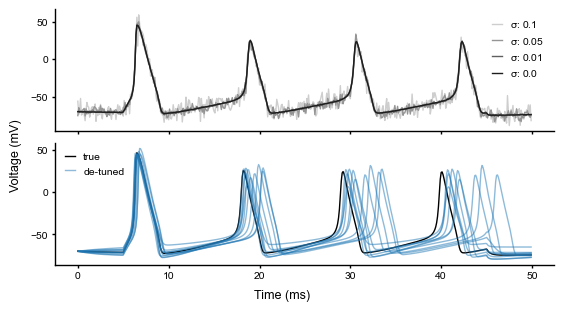

In [188]:
config = train_hybrid_on_hh_k()
data = Dataset.from_file("../" + config.val_fpath)

ts = data.Y.pop("time")[0]  # Get time array from first sample
noise_lvls = jnp.array([0.0, 0.01, 0.05, 0.1])[::-1] # invert for plotting order
keys = jr.split(jr.PRNGKey(0), noise_lvls.shape[0])

noisy_v = jax.tree.map(
    lambda x: jax.vmap(
        lambda noise_lvl, key: x + noise_lvl * jnp.max(jnp.abs(x)) * jr.normal(key, x.shape)
    )(noise_lvls, keys),
    data.Y,
)["v"].squeeze()


keys = jr.split(jr.key(0), 10)
def make_init_params(key, noise_lvl = 0.05):
    param_keys = jr.split(key, len(config.init_params))
    return {
        k: v + noise_lvl * jnp.abs(v) * jr.normal(k2, ())
        for (k, v), k2 in zip(config.init_params.items(), param_keys)
    }

init_params = jax.vmap(make_init_params)(keys)
repl_dict = {
    ".channels['k'].gk":".channels['node'].gx",
    ".channels['k'].ek":".channels['node'].ex",
    ".channels['k'].powx['n']":".channels['node'].powx['n']",
}
for new, old in repl_dict.items():
    init_params[new] = init_params.pop(old)



hh = HH([Na(), K(), Leak()], [StepCurrent(amp=15.0, start=5.0, end=45.0)])
dt = 0.1
ts = jnp.arange(0, 50.0, dt)

u0 = config.u_init

@eqx.filter_vmap(in_axes=(None, 0, None, None))
def v_integrate(model, params, u0, ts, ):
    _model = model.set(params)  # this should only set static params!
    _u0 = {**u0, **_model.initial_state}
    t, x = integrate(_model, ts, _u0)
    return t, x

_, u_base = integrate(hh, ts, u0)
_, u_init_noise = v_integrate(hh, init_params, u0, ts)

fig, ax = plt.subplots(2, 1, figsize=(FULL_WIDTH, 3), sharex=True, layout="constrained")
colors = plt.cm.Greys(jnp.linspace(0.3, 0.9, len(noise_lvls)))
for i, noise_lvl in enumerate(noise_lvls):
    ax[0].plot(ts, noisy_v[i], label=r"$\sigma$"+ f': {noise_lvl}', color=colors[i])
ax[0].legend(handlelength=1)

ax[1].plot(ts, u_base["v"].T, color="k")
ax[1].plot(ts, u_init_noise["v"].T, color="tab:blue", alpha=0.5)
ax[1].legend(["true", "de-tuned"], handlelength=1)
fig.supxlabel('Time (ms)')
fig.supylabel('Voltage (mV)')

plt.savefig("../figures/paper/tab_app.pdf", dpi=300, transparent=True, bbox_inches="tight")
plt.savefig("../figures/paper/tab_app.png", dpi=300, transparent=True, bbox_inches="tight")

In [265]:
import jaxley as jx
import pandas as pd
import time

ncomp = 1
swc_path = "../other/swc_files/morph_ca1_n120_single_point_soma.swc"
cell = jx.read_swc(swc_path, ncomp=ncomp)
num_comps = len(cell.nodes)

def _block_until_ready(tree):
    jax.tree.map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        tree,
    )

def _time_integrate(model, ts, init_state, num_repeats=10):
    out = integrate(model, ts, init_state)  # warmup / compile
    _block_until_ready(out)

    times = []
    for _ in range(num_repeats):
        start = time.perf_counter()
        out = integrate(model, ts, init_state)
        _block_until_ready(out)
        times.append(time.perf_counter() - start)

    return out, float(np.mean(times)), float(np.std(times))


def _time_forwardpass(model, ts, init_state, num_repeats=10):
    out = model(0.0, init_state)  # warmup / compile
    _block_until_ready(out)

    times = []
    for _ in range(num_repeats):
        start = time.perf_counter()
        out = model(0.0, init_state)
        _block_until_ready(out)
        times.append(time.perf_counter() - start)

    return out, float(np.mean(times)), float(np.std(times))

In [301]:
config = train_hybrid_on_hh_k()

EXP_DIR = "../results/sweeps/hh_channel_arch_sweep3/"
json_files = [f for f in os.listdir(EXP_DIR) if f.endswith(".json") and "tanh" in f]
filtered_experiments = pd.DataFrame(columns=["json_file", "width", "depth", "rmse"])
for json_file in json_files:
    with open(os.path.join(EXP_DIR, json_file), "r") as f:
        loaded_data = json.load(f)
        loaded_data["best_val_loss"]
        width = loaded_data["channel_model_kwargs"]["width_size"]
        depth = loaded_data["channel_model_kwargs"]["depth_size"]
        val_data = loaded_data["validation_data"]
        v_val = np.array(val_data["val"]["v"][0])
        v_pred = np.array(val_data["pred"]["v"][0])
        rmse_val = rmse(v_val, v_pred)
        filtered_experiments.loc[len(filtered_experiments)] = [json_file, width, depth, rmse_val]

# filter experiments for the ones that convered, to ensure integration runs smoothly
filtered_experiments = filtered_experiments.sort_values("rmse").drop_duplicates(subset=["width", "depth"], keep="first").reset_index(drop=True)

df_k_runtimes = pd.DataFrame(columns=["width", "depth", "mean_integrate_time", "std_integrate_time", "mean_forward_time", "std_forward_time"])

dt = 0.1
ts = jnp.arange(0, 50.0, dt)

hh_true = HH([Na(), K(), Leak()], [StepCurrent(amp=15.0, start=5.0, end=45.0)])
u0 = hh_true.init(0.0, config.u_init)

_, hh_k_mean_time, hh_k_std_time = _time_integrate(hh_true, ts, u0)
_, hh_k_fwd_time, hh_k_fwd_std = _time_forwardpass(hh_true, ts, u0)
print(f"hh_true integrate:   {hh_k_mean_time:.6f} ± {hh_k_std_time:.6f} s")
print(f"hh_true forward pass:   {hh_k_fwd_time:.6f} ± {hh_k_fwd_std:.6f} s")

row = {
    "width": 0,
    "depth": 0,
    "mean_integrate_time": hh_k_mean_time,
    "std_integrate_time": hh_k_std_time,
    "mean_forward_time": hh_k_fwd_time,
    "std_forward_time": hh_k_fwd_std,
}
df_k_runtimes = pd.concat([df_k_runtimes, pd.DataFrame([row])], ignore_index=True)

hh = config.hh_model
base_model_kwargs = config.channel_model_kwargs.copy()
for json_file in filtered_experiments["json_file"]:
    json_path = os.path.join(EXP_DIR, json_file)
    with open(json_path, "r") as f:
        loaded_data = json.load(f)
        kwargs = loaded_data["channel_model_kwargs"]
        width = kwargs["width_size"]
        depth = kwargs["depth_size"]
        kwargs["activation"] = jax.nn.tanh
        kwargs["last_layer_initializer"] = config.channel_model_kwargs["last_layer_initializer"]
        node = config.ChannelModel(key=jr.key(0),**kwargs)
        init_model = hh.insert(node).set(config.init_params)
        loaded_model = eqx.tree_deserialise_leaves(os.path.join(EXP_DIR, json_file.replace(".json", ".eqx")), init_model)
        
        _, hybrid_k_mean_time, hybrid_k_std_time = _time_integrate(loaded_model, ts, u0, num_repeats=50)
        _, hybrid_k_fwd_time, hybrid_k_fwd_std = _time_forwardpass(loaded_model, ts, u0, num_repeats=50)

        print(f"hh_hybrid integrate ({width}x{depth}): {hybrid_k_mean_time:.6f} ± {hybrid_k_std_time:.6f} s")
        print(f"hh_hybrid forward pass ({width}x{depth}): {hybrid_k_fwd_time:.6f} ± {hybrid_k_fwd_std:.6f} s")
        row = pd.DataFrame([{
            "width": width,
            "depth": depth,
            "mean_integrate_time": hybrid_k_mean_time,
            "std_integrate_time": hybrid_k_std_time,
            "mean_forward_time": hybrid_k_fwd_time,
            "std_forward_time": hybrid_k_fwd_std
        }])
        df_k_runtimes = pd.concat([df_k_runtimes, row], ignore_index=True)

hh_true integrate:   0.013591 ± 0.000373 s
hh_true forward pass:   0.001194 ± 0.000038 s
hh_hybrid integrate (64x2): 0.121479 ± 0.025816 s
hh_hybrid forward pass (64x2): 0.028915 ± 0.002760 s
hh_hybrid integrate (32x3): 0.069311 ± 0.011341 s
hh_hybrid forward pass (32x3): 0.040320 ± 0.004345 s
hh_hybrid integrate (64x3): 0.128304 ± 0.069955 s
hh_hybrid forward pass (64x3): 0.036889 ± 0.002944 s
hh_hybrid integrate (32x2): 0.074595 ± 0.010296 s
hh_hybrid forward pass (32x2): 0.025496 ± 0.002060 s
hh_hybrid integrate (128x2): 0.080483 ± 0.012434 s
hh_hybrid forward pass (128x2): 0.018569 ± 0.000859 s
hh_hybrid integrate (128x3): 0.120269 ± 0.018636 s
hh_hybrid forward pass (128x3): 0.027264 ± 0.001794 s
hh_hybrid integrate (16x3): 0.067979 ± 0.018830 s
hh_hybrid forward pass (16x3): 0.037073 ± 0.004771 s
hh_hybrid integrate (8x2): 0.038931 ± 0.004544 s
hh_hybrid forward pass (8x2): 0.017477 ± 0.001359 s
hh_hybrid integrate (8x3): 0.046963 ± 0.006839 s
hh_hybrid forward pass (8x3): 0.0239

In [302]:
df_k_runtimes["speedup_integrate"] = (df_k_runtimes["mean_integrate_time"].iloc[0] / df_k_runtimes["mean_integrate_time"]).astype(float)
df_k_runtimes["speedup_forward"] = (df_k_runtimes["mean_forward_time"].iloc[0] / df_k_runtimes["mean_forward_time"]).astype(float)

df_k_runtimes = df_k_runtimes.sort_values(["width", "depth"]).reset_index(drop=True)
df_k_runtimes

,width,depth,mean_integrate_time,std_integrate_time,mean_forward_time,std_forward_time,speedup_integrate,speedup_forward
0,0,0,0.013591,0.000373,0.001194,0.000038,1.000000,1.000000
1,8,2,0.038931,0.004544,0.017477,0.001359,0.349094,0.068313
2,8,3,0.046963,0.006839,0.0239,0.004004,0.289389,0.049953
3,16,2,0.039029,0.011193,0.015996,0.000945,0.348217,0.074638
4,16,3,0.067979,0.01883,0.037073,0.004771,0.199922,0.032203
5,32,2,0.074595,0.010296,0.025496,0.00206,0.182192,0.046827
6,32,3,0.069311,0.011341,0.04032,0.004345,0.196081,0.029610
7,64,2,0.121479,0.025816,0.028915,0.00276,0.111876,0.041289
8,64,3,0.128304,0.069955,0.036889,0.002944,0.105925,0.032364
9,128,2,0.080483,0.012434,0.018569,0.000859,0.168862,0.064295


In [13]:
df_k_runtimes = pd.read_csv("../results/runtimes_hh_k.csv")
df_k_runtimes

,width,depth,mean_integrate_time,std_integrate_time,mean_forward_time,std_forward_time,speedup_integrate,speedup_forward
0,0,0,0.080802,0.000815,0.002709,0.000850,1.000000,1.000000
1,8,2,0.090041,0.001740,0.016841,0.001179,0.897401,0.160862
2,8,3,0.093383,0.002232,0.022207,0.000162,0.865278,0.121991
3,16,2,0.046955,0.005394,0.016689,0.000664,1.720844,0.162326
4,16,3,0.053694,0.009055,0.016450,0.000951,1.504856,0.164687
5,32,2,0.055332,0.008245,0.016893,0.000270,1.460314,0.160363
6,32,3,0.065286,0.007621,0.022306,0.000976,1.237671,0.121453
7,64,2,0.059800,0.008874,0.016649,0.001450,1.351211,0.162718
8,64,3,0.071730,0.006412,0.023005,0.000257,1.126481,0.117762
9,128,2,0.080404,0.007459,0.016921,0.001088,1.004959,0.160099


In [9]:
latex_table_k = df_to_latex(df_k_runtimes, highlight_vals=[None, None, "min", None, "min", None, "max", "max"], mean_pm_std=True, float_format="%.3f", col_fmt="ccccc", hlines=False)
print(latex_table_k)

\begin{table}[ht]
\centering
\begin{tabular}{ccccc}
\toprule
width & depth & integrate_time & forward_time & speedup_integrate & speedup_forward \\
\midrule
0 & 0 & 0.081 $\pm$ 0.001 & \textbf{0.003 $\pm$ 0.001} & 1.000 & \textbf{1.000} \\
8 & 2 & 0.090 $\pm$ 0.002 & 0.017 $\pm$ 0.001 & 0.897 & 0.161 \\
8 & 3 & 0.093 $\pm$ 0.002 & 0.022 $\pm$ 0.000 & 0.865 & 0.122 \\
16 & 2 & \textbf{0.047 $\pm$ 0.005} & 0.017 $\pm$ 0.001 & \textbf{1.721} & 0.162 \\
16 & 3 & 0.054 $\pm$ 0.009 & 0.016 $\pm$ 0.001 & 1.505 & 0.165 \\
32 & 2 & 0.055 $\pm$ 0.008 & 0.017 $\pm$ 0.000 & 1.460 & 0.160 \\
32 & 3 & 0.065 $\pm$ 0.008 & 0.022 $\pm$ 0.001 & 1.238 & 0.121 \\
64 & 2 & 0.060 $\pm$ 0.009 & 0.017 $\pm$ 0.001 & 1.351 & 0.163 \\
64 & 3 & 0.072 $\pm$ 0.006 & 0.023 $\pm$ 0.000 & 1.126 & 0.118 \\
128 & 2 & 0.080 $\pm$ 0.007 & 0.017 $\pm$ 0.001 & 1.005 & 0.160 \\
128 & 3 & 0.115 $\pm$ 0.005 & 0.023 $\pm$ 0.000 & 0.705 & 0.119 \\
\bottomrule
\end{tabular}

\end{table}


In [304]:
print(latex_to_str(latex_table_k))

| width | depth | integrate_time | forward_time | speedup_integrate | speedup_forward |
|---:|---:|---:|---:|---:|---:|
| 0 | 0 | **0.014 ± 0.000** | **0.001 ± 0.000** | **1.000** | **1.000** |
| 8 | 2 | 0.039 ± 0.005 | 0.017 ± 0.001 | 0.349 | 0.068 |
| 8 | 3 | 0.047 ± 0.007 | 0.024 ± 0.004 | 0.289 | 0.050 |
| 16 | 2 | 0.039 ± 0.011 | 0.016 ± 0.001 | 0.348 | 0.075 |
| 16 | 3 | 0.068 ± 0.019 | 0.037 ± 0.005 | 0.200 | 0.032 |
| 32 | 2 | 0.075 ± 0.010 | 0.025 ± 0.002 | 0.182 | 0.047 |
| 32 | 3 | 0.069 ± 0.011 | 0.040 ± 0.004 | 0.196 | 0.030 |
| 64 | 2 | 0.121 ± 0.026 | 0.029 ± 0.003 | 0.112 | 0.041 |
| 64 | 3 | 0.128 ± 0.070 | 0.037 ± 0.003 | 0.106 | 0.032 |
| 128 | 2 | 0.080 ± 0.012 | 0.019 ± 0.001 | 0.169 | 0.064 |
| 128 | 3 | 0.120 ± 0.019 | 0.027 ± 0.002 | 0.113 | 0.044 |


In [ ]:
config = train_hybrid_on_multicomp()

EXP_DIR = "../results/sweeps/multicomp_sweep2/"
json_files = [f for f in os.listdir(EXP_DIR) if f.endswith(".json")]
filtered_experiments = pd.DataFrame(columns=["json_file", "width", "depth", "num_latents", "rmse"])
for json_file in json_files:
    with open(os.path.join(EXP_DIR, json_file), "r") as f:
        loaded_data = json.load(f)
        has_weights = os.path.exists(os.path.join(EXP_DIR, json_file.replace(".json", ".eqx")))
        if "validation_data" in loaded_data and has_weights:
            width = loaded_data["channel_model_kwargs"]["width_size"]
            depth = loaded_data["channel_model_kwargs"]["depth_size"]
            num_latents = len(loaded_data["channel_model_kwargs"]["latent_states"])
            val_data = loaded_data["validation_data"]
            v_val = np.array(val_data["val"]["v"][0])
            v_pred = np.array(val_data["pred"]["v"][0])
            rmse_val = rmse(v_val, v_pred)
        else:
            if not has_weights:
                print(f"model weights not found for {json_file}, skipping for runtime eval")
            else:
                print(f"validation data not found in {json_file}, skipping for runtime eval")
            width = np.nan
            depth = np.nan
            num_latents = np.nan
            rmse_val = np.nan
        filtered_experiments.loc[len(filtered_experiments)] = [json_file, width, depth, num_latents, rmse_val]

# filter experiments for the ones that convered, to ensure integration runs smoothly
filtered_experiments = filtered_experiments.sort_values("rmse").drop_duplicates(subset=["width", "depth", "num_latents"], keep="first").reset_index(drop=True)
filtered_experiments = filtered_experiments.dropna(subset=["width", "depth", "num_latents"]).reset_index(drop=True)


dt = 0.1
ts = jnp.arange(0, 70.0, dt)

hh_true = hh_base = config.hh_model
u0_base = {k:v for k,v in config.u_init.items() if not k.startswith("z")}

_, hh_single_mean_time, hh_single_std_time = _time_integrate(hh_true, ts, u0_base)
_, hh_single_fwd_time, hh_single_fwd_std = _time_forwardpass(hh_true, ts, u0_base)
print(f"hh_true integrate:   {hh_single_mean_time:.6f} ± {hh_single_std_time:.6f} s")
print(f"hh_true forward pass:   {hh_single_fwd_time:.6f} ± {hh_single_fwd_std:.6f} s")

df_multicomp_runtimes = pd.DataFrame(columns=["width", "depth", "num_latents", "mean_integrate_time", "std_integrate_time", "mean_forward_time", "std_forward_time"])
row = {
    "width": 0,
    "depth": 0,
    "num_latents": 0,
    "mean_integrate_time": hh_single_mean_time,
    "std_integrate_time": hh_single_std_time,
    "mean_forward_time": hh_single_fwd_time,
    "std_forward_time": hh_single_fwd_std,
}
df_multicomp_runtimes = pd.concat([df_multicomp_runtimes, pd.DataFrame([row])], ignore_index=True)

hh = config.hh_model
base_model_kwargs = config.channel_model_kwargs.copy()
for json_file in json_files:
    json_path = os.path.join(EXP_DIR, json_file)
    with open(json_path, "r") as f:
        loaded_data = json.load(f)
        kwargs = loaded_data["channel_model_kwargs"]
        width = kwargs["width_size"]
        depth = kwargs["depth_size"]
        model_latents = loaded_data["channel_model_kwargs"]["latent_states"]
        num_latents = len(model_latents)
        
        kwargs["activation"] = jax.nn.tanh
        kwargs["last_layer_initializer"] = config.channel_model_kwargs["last_layer_initializer"]
        node = config.ChannelModel(key=jr.key(0),**kwargs)
        init_model = hh.insert(node).set(config.init_params)
        loaded_model = eqx.tree_deserialise_leaves(os.path.join(EXP_DIR, json_file.replace(".json", ".eqx")), init_model)
        u0 = loaded_model.init(0.0, config.u_init)
        u0 = {k:v for k,v in u0.items() if not k.startswith("z") or k in model_latents}
        
        _, hybrid_multi_mean_time, hybrid_multi_std_time = _time_integrate(loaded_model, ts, u0, num_repeats=50)
        _, hybrid_multi_fwd_time, hybrid_multi_fwd_std = _time_forwardpass(loaded_model, ts, u0, num_repeats=50)

        print(f"hh_hybrid integrate ({width}x{depth}x{num_latents}): {hybrid_multi_mean_time:.6f} ± {hybrid_multi_std_time:.6f} s")
        print(f"hh_hybrid forward pass ({width}x{depth}x{num_latents}): {hybrid_multi_fwd_time:.6f} ± {hybrid_multi_fwd_std:.6f} s")
        row = pd.DataFrame([{
            "width": width,
            "depth": depth,
            "num_latents": num_latents,
            "mean_integrate_time": hybrid_multi_mean_time,
            "std_integrate_time": hybrid_multi_std_time,
            "mean_forward_time": hybrid_multi_fwd_time,
            "std_forward_time": hybrid_multi_fwd_std
        }])
        df_multicomp_runtimes = pd.concat([df_multicomp_runtimes, row], ignore_index=True)

df_multicomp_runtimes[r"$N_{comp}$"] = 1
multi_comp_row = {r"$N_{comp}$": num_comps, "width": 0, "depth": 0, "num_latents": 0, "mean_integrate_time": hh_single_mean_time * num_comps, "std_integrate_time": hh_single_std_time, "mean_forward_time": hh_single_fwd_time * num_comps, "std_forward_time": hh_single_fwd_std}
df_multicomp_runtimes = pd.concat([df_multicomp_runtimes, pd.DataFrame([multi_comp_row])], ignore_index=True)

df_multicomp_runtimes[r"$\text{speedup}_{\text{integrate}}$"] = ((multi_comp_row["mean_integrate_time"]) / df_multicomp_runtimes["mean_integrate_time"]).astype(float)
df_multicomp_runtimes[r"$\text{speedup}_{\text{forward}}$"] = ((multi_comp_row["mean_forward_time"]) / df_multicomp_runtimes["mean_forward_time"]).astype(float)

df_multicomp_runtimes = df_multicomp_runtimes.sort_values(["num_latents", "width", "depth"]).reset_index(drop=True) # fold in num latents to make the table smaller
df_multicomp_runtimes

model weights not found for multicomp_latent4_seed11_2026_05_04_14_56_37_090143.json, skipping for runtime eval
model weights not found for multicomp_latent4_seed10_2026_05_04_14_52_07_243012.json, skipping for runtime eval
hh_true integrate:   0.023375 ± 0.001437 s
hh_true forward pass:   0.004526 ± 0.000575 s
hh_hybrid integrate (64x2x2): 0.115688 ± 0.030700 s
hh_hybrid forward pass (64x2x2): 0.006318 ± 0.000202 s
hh_hybrid integrate (256x2x4): 0.525655 ± 0.069600 s
hh_hybrid forward pass (256x2x4): 0.010217 ± 0.001314 s


,width,depth,num_latents,mean_integrate_time,std_integrate_time,mean_forward_time,std_forward_time,$N_{comp}$,$\text{speedup}_{\text{integrate}}$,$\text{speedup}_{\text{forward}}$
0,0,0,0,0.023375,0.001437,0.004526,0.000575,1,154.000000,154.000000
1,0,0,0,3.599801,0.001437,0.697078,0.000575,154,1.000000,1.000000
2,64,2,2,0.115688,0.0307,0.006318,0.000202,1,31.116402,110.337006
3,256,2,4,0.525655,0.0696,0.010217,0.001314,1,6.848218,68.224690


In [33]:
df_multicomp_runtimes = pd.read_csv("../results/runtimes_multicomp.csv")
df_multicomp_runtimes = df_multicomp_runtimes.sort_values(["width", "depth", "num_latents"]).reset_index(drop=True) # fold in num latents to make the table smaller
df_multicomp_runtimes = df_multicomp_runtimes.drop(columns=["num_latents"]).groupby(["width", "depth", "$N_{comp}$"], as_index=False).mean()
df_multicomp_runtimes["speedup_integrate"] = df_multicomp_runtimes["mean_integrate_time"].iloc[1] / df_multicomp_runtimes["mean_integrate_time"]
df_multicomp_runtimes["speedup_forward"] = df_multicomp_runtimes["mean_forward_time"].iloc[1] / df_multicomp_runtimes["mean_forward_time"]
df_multicomp_runtimes

,width,depth,$N_{comp}$,mean_integrate_time,std_integrate_time,mean_forward_time,std_forward_time,speedup_integrate,speedup_forward
0,0,0,1,0.046664,0.000999,0.003398,0.000992,23.781955,9.422051
1,0,0,154,1.109761,0.043783,0.032020,0.000296,1.000000,1.000000
2,32,2,1,0.117050,0.009764,0.008026,0.000813,9.481087,3.989647
3,32,3,1,0.129928,0.009838,0.009254,0.000704,8.541347,3.460302
4,64,2,1,0.131727,0.007727,0.007947,0.000699,8.424679,4.029067
5,64,3,1,0.166810,0.007586,0.009206,0.000585,6.652866,3.478141
6,128,2,1,0.184336,0.008715,0.008021,0.000571,6.020325,3.991867
7,128,3,1,0.266606,0.011192,0.009284,0.000407,4.162549,3.448871
8,256,2,1,0.672973,0.018840,0.008093,0.000601,1.649042,3.956468
9,256,3,1,1.555717,0.057925,0.009130,0.000430,0.713344,3.507252


In [35]:
latex_table_multicomp = df_to_latex(df_multicomp_runtimes, highlight_vals=[None, None, None, "min", None, "min", None, "max", "max"], mean_pm_std=True, float_format="%.3f", hlines=False, col_fmt="cccccccc")
print(latex_table_multicomp)

\begin{table}[ht]
\centering
\begin{tabular}{cccccccc}
\toprule
width & depth & $N_{comp}$ & integrate_time & forward_time & speedup_integrate & speedup_forward \\
\midrule
0 & 0 & 1 & \textbf{0.047 $\pm$ 0.001} & \textbf{0.003 $\pm$ 0.001} & \textbf{23.782} & \textbf{9.422} \\
0 & 0 & 154 & 1.110 $\pm$ 0.044 & 0.032 $\pm$ 0.000 & 1.000 & 1.000 \\
32 & 2 & 1 & 0.117 $\pm$ 0.010 & 0.008 $\pm$ 0.001 & 9.481 & 3.990 \\
32 & 3 & 1 & 0.130 $\pm$ 0.010 & 0.009 $\pm$ 0.001 & 8.541 & 3.460 \\
64 & 2 & 1 & 0.132 $\pm$ 0.008 & 0.008 $\pm$ 0.001 & 8.425 & 4.029 \\
64 & 3 & 1 & 0.167 $\pm$ 0.008 & 0.009 $\pm$ 0.001 & 6.653 & 3.478 \\
128 & 2 & 1 & 0.184 $\pm$ 0.009 & 0.008 $\pm$ 0.001 & 6.020 & 3.992 \\
128 & 3 & 1 & 0.267 $\pm$ 0.011 & 0.009 $\pm$ 0.000 & 4.163 & 3.449 \\
256 & 2 & 1 & 0.673 $\pm$ 0.019 & 0.008 $\pm$ 0.001 & 1.649 & 3.956 \\
256 & 3 & 1 & 1.556 $\pm$ 0.058 & 0.009 $\pm$ 0.000 & 0.713 & 3.507 \\
512 & 2 & 1 & 2.629 $\pm$ 0.066 & 0.008 $\pm$ 0.001 & 0.422 & 3.903 \\
512 & 3 & 1 & 4

In [326]:
print(latex_to_str(latex_table_multicomp))

| width | depth | num_latents | integrate_time | forward_time | N_comp | \textspeedup_\textintegrate | \textspeedup_\textforward |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 0 | 0 | 0 | **0.025 ± 0.003** | **0.004 ± 0.000** | 1 | **1.000** | **1.000** |
| 0 | 0 | 0 | 3.369 ± 0.001 | 0.604 ± 0.000 | 154 | 0.008 | 0.007 |
| 32 | 2 | 1 | 0.112 ± 0.026 | 0.009 ± 0.001 | 1 | 0.227 | 0.444 |
| 32 | 2 | 1 | 0.087 ± 0.011 | 0.008 ± 0.000 | 1 | 0.292 | 0.522 |
| 32 | 3 | 1 | 0.064 ± 0.009 | 0.007 ± 0.000 | 1 | 0.396 | 0.610 |
| 32 | 3 | 1 | 0.086 ± 0.011 | 0.009 ± 0.000 | 1 | 0.295 | 0.456 |
| 32 | 3 | 1 | 0.079 ± 0.009 | 0.007 ± 0.000 | 1 | 0.323 | 0.588 |
| 64 | 2 | 1 | 0.083 ± 0.010 | 0.006 ± 0.000 | 1 | 0.309 | 0.729 |
| 64 | 2 | 1 | 0.123 ± 0.028 | 0.007 ± 0.000 | 1 | 0.208 | 0.577 |
| 64 | 2 | 1 | 0.128 ± 0.016 | 0.008 ± 0.000 | 1 | 0.200 | 0.510 |
| 64 | 3 | 1 | 0.128 ± 0.033 | 0.008 ± 0.001 | 1 | 0.200 | 0.532 |
| 64 | 3 | 1 | 0.438 ± 0.286 | 0.021 ± 0.004 | 1 | 0.058 | 0.204 |
| 64 | 

In [ ]:
def _block_until_ready(tree):
    jax.tree.map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        tree,
    )

def _time_jx_integrate(model, num_repeats=10):
    out = jx.integrate(model)  # warmup / compile
    _block_until_ready(out)

    times = []
    for _ in range(num_repeats):
        start = time.perf_counter()
        out = jx.integrate(model)
        _block_until_ready(out)
        times.append(time.perf_counter() - start)

    return out, float(np.mean(times)), float(np.std(times))

In [8]:
import jaxley as jx
from jaxley.channels.pospischil import Na, K, Leak, Km
import pandas as pd

ncomp = 1
swc_path = "../other/swc_files/morph_ca1_n120_single_point_soma.swc"
ra = 100.0
cell = jx.read_swc(swc_path, ncomp=ncomp)
cell.insert(Na())
cell.insert(K())
cell.insert(Leak())
cell.insert(Km())

cell.set("axial_resistivity", ra)

dt = 0.025
i_delay = 10.0
i_dur = 40.0
i_amp = 0.65
t_max = 70.0

time_vec = jnp.arange(0, t_max+2*dt, dt)

cell.delete_recordings()
cell.delete_stimuli()

current = jx.step_current(i_delay, i_dur, i_amp, dt, t_max)

cell.soma.comp(0).record()
cell.soma.comp(0).stimulate(current)

cell.init_states()
ts_sim = jnp.arange(0.0, t_max+dt, dt)
vs_multicomp = jx.integrate(cell)[:, :-1]

soma_data = cell.soma.nodes.iloc[0]

soma = jx.Compartment()
soma.set("radius", soma_data["radius"])
soma.set("length", soma_data["length"])
soma.insert(Na())
soma.insert(K())
soma.insert(Leak())
soma.insert(Km())

soma.record()
soma.stimulate(current*0.04)
soma.init_states()

v_soma = jx.integrate(soma)[:, :-1]

Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.


In [11]:
_, jx_multi_mean_time, jx_multi_std_time = _time_jx_integrate(cell)
_, jx_single_mean_time, jx_single_std_time = _time_jx_integrate(soma)
factor = jx_multi_mean_time / jx_single_mean_time

print(f"jx multicomp integrate: {jx_multi_mean_time:.6f} ± {jx_multi_std_time:.6f} s")
print(f"jx single comp integrate: {jx_single_mean_time:.6f} ± {jx_single_std_time:.6f} s")
print(f"Multi-comp overhead: {factor:.2f}x")

jx multicomp integrate: 1.988654 ± 0.772274 s
jx single comp integrate: 0.686172 ± 0.138371 s
Multi-comp overhead: 2.90x
